In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np 
import pandas as pd 

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statistics

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score,classification_report,confusion_matrix

In [5]:
df_train_original = pd.read_csv('test.csv')
df_train = df_train_original.copy()
df_train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [6]:
df_train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [7]:
print('Train Data Size : ',df_train.shape)

Train Data Size :  (50000, 27)


In [8]:
df_train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [10]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,42502.0,4182.004291,3174.109304,303.645417,1625.188333,3086.305000,5934.189094,15204.633333
Num_Bank_Accounts,50000.0,16.838260,116.396848,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,50000.0,22.921480,129.314804,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,50000.0,68.772640,451.602363,1.000000,8.000000,13.000000,20.000000,5799.000000
Delay_from_due_date,50000.0,21.052640,14.860397,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,48965.0,30.080200,196.984121,0.000000,4.000000,7.000000,10.000000,2593.000000
Credit_Utilization_Ratio,50000.0,32.279581,5.106238,20.509652,28.061040,32.280390,36.468591,48.540663
Total_EMI_per_month,50000.0,1491.304305,8595.647887,0.000000,32.222388,74.733349,176.157491,82398.000000


In [11]:
df_train.describe(exclude=np.number).T

,count,unique,top,freq
ID,50000,50000,0x160a,1
Customer_ID,50000,12500,CUS_0xd40,4
Month,50000,4,September,12500
Name,44985,10139,Stevex,22
Age,50000,976,39,1493
SSN,50000,12501,#F%$D@*&8,2828
Occupation,50000,16,_______,3438
Annual_Income,50000,16121,109945.32,8
Num_of_Loan,50000,263,2,7173
Type_of_Loan,44296,6260,Not Specified,704


In [12]:
def get_column_details(df,column):
    print("Details of",column,"column")
    
    print("\nDataType: ",df[column].dtype)
    
    count_null = df[column].isnull().sum()
    if count_null==0:
        print("\nThere are no null values")
    elif count_null>0:
        print("\nThere are ",count_null," null values")

    print("\nNumber of Unique Values: ",df[column].nunique())
    
   
    print("\nDistribution of column:\n")
    print(df[column].value_counts())

In [13]:
def fill_missing_with_group_mode(df, groupby, column):      
    print("\nNo. of missing values before filling with group mode:",df[column].isnull().sum())
    

    mode_per_group = df.groupby(groupby)[column].transform(lambda x: x.mode().iat[0])
    df[column] = df[column].fillna(mode_per_group)
    
    print("\nNo. of missing values after filling with group mode:",df[column].isnull().sum())

In [14]:
def clean_categorical_field(df,groupby,column,replace_value=None):
    print("\n-----------------------------------------------------")
    print("\nCleaning steps ")
    
    if replace_value!=None:
        df[column] = df[column].replace(replace_value,np.nan)
        print(f"\nGarbage value {replace_value} is replaced with np.nan")

    fill_missing_with_group_mode(df,groupby,column)

In [15]:
def fix_inconsistent_values(df, groupby, column):      
    print("\nExisting Min, Max Values:", df[column].apply([min, max]), sep='\n', end='\n')   
    
    df_dropped = df[df[column].notna()].groupby(groupby)[column].apply(list)
    x, y = df_dropped.apply(lambda x: stats.mode(x)).apply([min, max])
    mini, maxi = x[0][0], y[0][0]


    col = df[column].apply(lambda x: np.NaN if ((x<mini)|(x>maxi)|(x<0)) else x)

    mode_by_group = df.groupby(groupby)[column].transform(lambda x: x.mode()[0] if not x.mode().empty else np.NaN)
    df[column] = col.fillna(mode_by_group)
    df[column].fillna(df[column].mean(),inplace=True)

    print("\nAfter Cleaning Min, Max Values:", df[column].apply([min, max]), sep='\n', end='\n') 
    print("\nNo. of Unique values after Cleaning:",df[column].nunique())
    print("\nNo. of Null values after Cleaning:",df[column].isnull().sum())

In [16]:
def clean_numerical_field(df,groupby,column,strip=None,datatype=None,replace_value=None):
    print("\n-----------------------------------------------------")
    print("\nCleaning steps ")
    
    if replace_value!=None:
        df[column] = df[column].replace(replace_value,np.nan)
        print(f"\nGarbage value {replace_value} is replaced with np.nan")

    if df[column].dtype == object and strip is not None:
        df[column] = df[column].str.strip(strip)
        print(f"\nTrailing & leading {strip} are removed")

    if datatype is not None:
        df[column] = df[column].astype(datatype)
        print(f"\nDatatype of {column} is changed to {datatype}")

    fix_inconsistent_values(df, groupby, column)

In [17]:
def plot_countplot(df,column,user_friendly_column_name,rotation=0):
    print("\n-----------------------------------------------------")
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep" 
    sns.set_palette(palette)
    
    sns.countplot(data=df, x=column)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [18]:
def plot_displot(df,column,user_friendly_column_name,rotation=0,bins=20):
    print("\n-----------------------------------------------------")
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep" 
    sns.set_palette(palette)
    
    sns.displot(data=df, x=column, kde=True, bins=bins)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [19]:
def plot_stacked_bar(df,column1,column2,rotation=0):
    print("\n-----------------------------------------------------")
    print(f'\n{column1} & {column2} Distribution')
    palette = "deep" 
    sns.set_palette(palette)

    pd.crosstab(df[column1], df[column2]).plot(kind='bar', stacked=True)
    
    plt.xlabel(f'{column1}')
    plt.ylabel('Number of Records')
    plt.title(f'{column1} & {column2} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

# 4.3 Categorical Variables 
## Credit Score
### Summary

### There are 3 different Credit Score - Standard, Good & Poor.
### Distribution of credit score -

### a) Standard - 53%

### b) Poor - 29%

### c) Good - 17%

### There are no null values for Credit Score.

In [20]:
print(df_train.columns)

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')


Details of Credit_Mix column

DataType:  object

There are no null values

Number of Unique Values:  4

Distribution of column:

Credit_Mix
Standard    18379
Good        12260
_            9805
Bad          9556
Name: count, dtype: int64

-----------------------------------------------------

Credit Mix Distribution


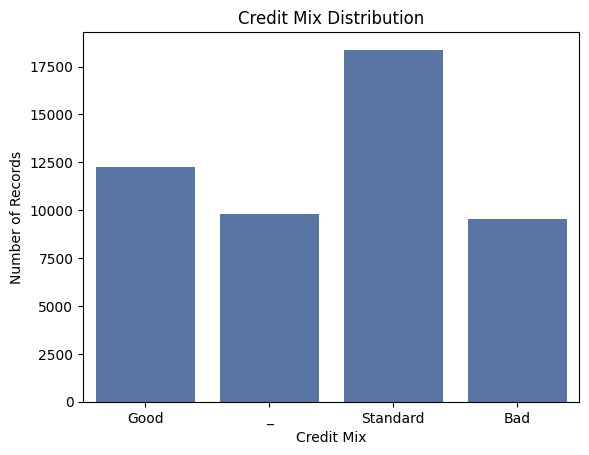

In [21]:
column_name = 'Credit_Mix'
user_friendly_name = 'Credit Mix'

# Get Details
get_column_details(df_train, column_name)

# Plot Graph
plot_countplot(df_train, column_name, user_friendly_name)


## ID 
## Summary

### 1. There are 100000 distinct records and no null values present.

In [22]:
get_column_details(df_train,'ID')

Details of ID column

DataType:  object

There are no null values

Number of Unique Values:  50000

Distribution of column:

ID
0x160a     1
0x19cd8    1
0x19c9a    1
0x19c9b    1
0x19c9c    1
          ..
0xd95e     1
0xd95f     1
0xd960     1
0xd961     1
0x25ff1    1
Name: count, Length: 50000, dtype: int64


## Customer ID¶
## Summary

### 1. We have record of 12500 unique customers.
### 2. Same customer can have different credit score. It means that on the basis of other values ### customer credit score can change.

In [23]:
get_column_details(df_train,'Customer_ID')

Details of Customer_ID column

DataType:  object

There are no null values

Number of Unique Values:  12500

Distribution of column:

Customer_ID
CUS_0xd40     4
CUS_0x9bf4    4
CUS_0x5ae3    4
CUS_0xbe9a    4
CUS_0x4874    4
             ..
CUS_0x2eb4    4
CUS_0x7863    4
CUS_0x9d89    4
CUS_0xc045    4
CUS_0x942c    4
Name: count, Length: 12500, dtype: int64


In [24]:
df_train.groupby(['Customer_ID'])['Credit_Mix'].nunique()

Customer_ID
CUS_0x1000    1
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x1013    2
             ..
CUS_0xff3     2
CUS_0xff4     2
CUS_0xff6     1
CUS_0xffc     1
CUS_0xffd     1
Name: Credit_Mix, Length: 12500, dtype: int64

### Month¶
### Summary

### 1. In the training dataset, we have credit score for each customer over the course of 8 months(from January to August).
### 2. Converted Month column from object to datetime value so that it can be further use for model building.
### 3. Distribution of Credit_Scrore across different months is similar.

Details of Month column

DataType:  object

There are no null values

Number of Unique Values:  4

Distribution of column:

Month
September    12500
October      12500
November     12500
December     12500
Name: count, dtype: int64

-----------------------------------------------------

Month & Credit_Mix Distribution


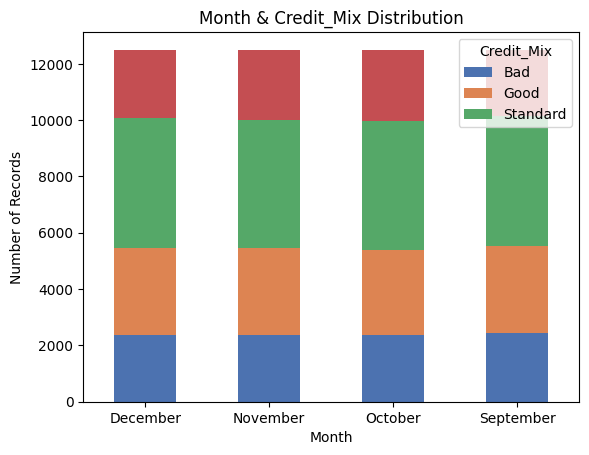

In [25]:
column_name = 'Month'

#Get Details
get_column_details(df_train,column_name)

#Plot Distrbution with Credit_Score
plot_stacked_bar(df_train,column_name,'Credit_Mix')

In [26]:
df_train['Month'] = pd.to_datetime(df_train.Month, format='%B').dt.month

In [27]:
def fill_missing_with_group_mode(df, groupby, column):      
    print("\nNo. of missing values before filling with group mode:", df[column].isnull().sum())
    
    mode_per_group = df.groupby(groupby)[column].transform(
        lambda x: x.mode().iat[0] if not x.mode().empty else np.nan
    )
    
    df[column] = df[column].fillna(mode_per_group)
    
    print("\nNo. of missing values after filling with group mode:", df[column].isnull().sum())


In [28]:
column_name = 'SSN'
group_by = 'Customer_ID'
garbage_value = '#F%$D@*&8'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_categorical_field(df_train,group_by,column_name,garbage_value)

Details of SSN column

DataType:  object

There are no null values

Number of Unique Values:  12501

Distribution of column:

SSN
#F%$D@*&8      2828
821-00-0265       4
756-60-6274       4
089-19-7596       4
905-14-5788       4
               ... 
332-96-0334       1
611-21-4406       1
326-89-0421       1
789-15-7049       1
715-49-4883       1
Name: count, Length: 12501, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value #F%$D@*&8 is replaced with np.nan

No. of missing values before filling with group mode: 2828

No. of missing values after filling with group mode: 0


Details of Occupation column

DataType:  object

There are no null values

Number of Unique Values:  16

Distribution of column:

Occupation
_______          3438
Lawyer           3324
Engineer         3212
Architect        3195
Mechanic         3168
Developer        3146
Accountant       3133
Media_Manager    3130
Scientist        3104
Teacher          3103
Entrepreneur     3103
Journalist       3037
Doctor           3027
Manager          3000
Musician         2947
Writer           2933
Name: count, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value _______ is replaced with np.nan

No. of missing values before filling with group mode: 3438

No. of missing values after filling with group mode: 0

-----------------------------------------------------

Occupation & Credit_Mix Distribution


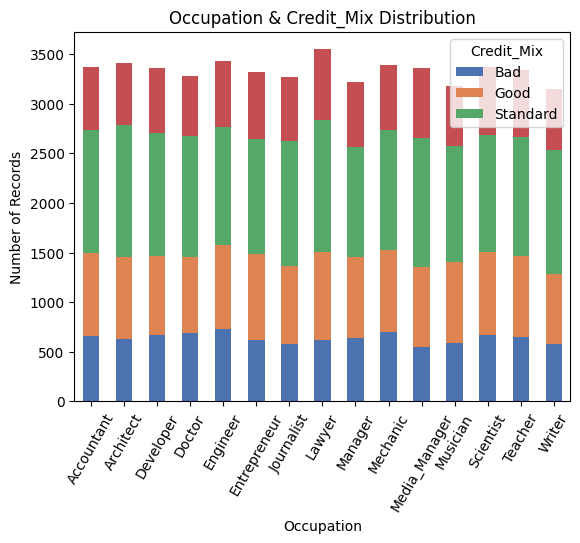

In [29]:
column_name = 'Occupation'
group_by = 'Customer_ID'
garbage_value = '_______'
user_friendly_name = 'Occupation'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_categorical_field(df_train,group_by,column_name,garbage_value)

#Plot Distribution with Credit_Score
plot_stacked_bar(df_train,column_name,'Credit_Mix',rotation=60)

In [30]:
get_column_details(df_train,'Type_of_Loan')

Details of Type_of_Loan column

DataType:  object

There are  5704  null values

Number of Unique Values:  6260

Distribution of column:

Type_of_Loan
Not Specified                                                                                                                         704
Credit-Builder Loan                                                                                                                   640
Personal Loan                                                                                                                         636
Debt Consolidation Loan                                                                                                               632
Student Loan                                                                                                                          620
                                                                                                                                     ... 
Not Specified, Mortga

In [31]:
df_train['Type_of_Loan'] = df_train['Type_of_Loan'].replace(np.NaN, 'Not Specified')


## Credit Mix
## Summary

### 1. There are 3 types of Credit Mix - Standard, Good, Bad
### 2. About 20k records of Credit Mix is marked as a garbage value (_).
### 3. Steps to Clean Credit Mix Field -

#### i. Replace garbage value with np.nan

#### ii. Assign same Credit Mix value for each customer ID`

In [32]:
print(df_train.columns)


Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')


Details of Credit_Mix column

DataType:  object

There are no null values

Number of Unique Values:  4

Distribution of column:

Credit_Mix
Standard    18379
Good        12260
_            9805
Bad          9556
Name: count, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value _ is replaced with np.nan

No. of missing values before filling with group mode: 9805

No. of missing values after filling with group mode: 84

-----------------------------------------------------

Credit_Mix & Credit_Mix Distribution


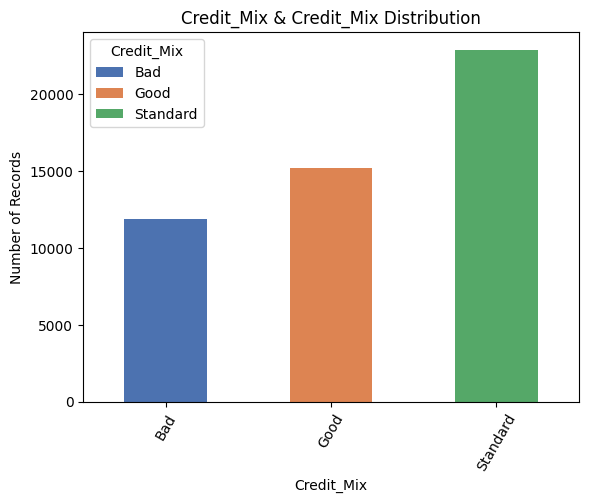

Details of Credit_Mix column

DataType:  object

There are  84  null values

Number of Unique Values:  3

Distribution of column:

Credit_Mix
Standard    22896
Good        15168
Bad         11852
Name: count, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value _ is replaced with np.nan

No. of missing values before filling with group mode: 84

No. of missing values after filling with group mode: 84

-----------------------------------------------------

Credit_Mix & Credit_Mix Distribution


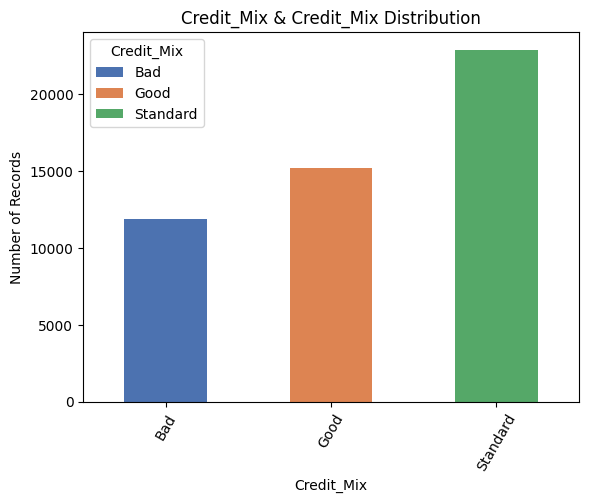

In [33]:
column_name = 'Credit_Mix'
group_by = 'Customer_ID'
garbage_value = '_'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_categorical_field(df_train,group_by,column_name,garbage_value)

#Plot Distribution with Credit_Score
plot_stacked_bar(df_train, column_name, 'Credit_Mix', rotation=60)

group_by = 'Customer_ID'
garbage_value = '_'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_categorical_field(df_train,group_by,column_name,garbage_value)

#Plot Distribution with Credit_Score
plot_stacked_bar(df_train,column_name,'Credit_Mix',rotation=60)

Details of Payment_of_Min_Amount column

DataType:  object

There are no null values

Number of Unique Values:  3

Distribution of column:

Payment_of_Min_Amount
Yes    26158
No     17849
NM      5993
Name: count, dtype: int64

-----------------------------------------------------

Payment_of_Min_Amount & Credit_Mix Distribution


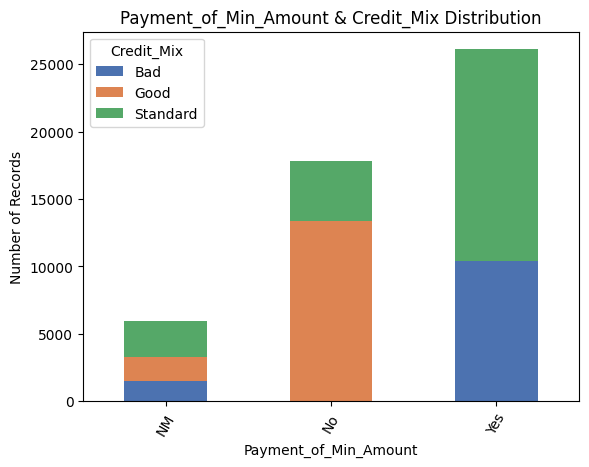

In [34]:
column_name = 'Payment_of_Min_Amount'

#Get Details
get_column_details(df_train,column_name)

#Plot Distribution with Credit_Score
plot_stacked_bar(df_train,column_name,'Credit_Mix',rotation=60)

### Payment Behaviour
### Summary

### 1. There are 6 unique values of Payment Behaviour -

#### Low_spent_Small_value_payments
#### High_spent_Medium_value_payments
#### Low_spent_Medium_value_payments
#### High_spent_Large_value_payments
#### High_spent_Small_value_payments
#### Low_spent_Large_value_payments

#### 2. Amount 27% of records are for Low_spent_Small_value_payments

#### 3. For 7.6k records, Payment Behaviour is filled with garbage value

#### 4. Steps to Clean Payment Behaviour Field -

##### i. Replace garbage value with np.nan

##### ii. Assign same Payment Behaviour value for each customer ID

Details of Payment_Behaviour column

DataType:  object

There are no null values

Number of Unique Values:  7

Distribution of column:

Payment_Behaviour
Low_spent_Small_value_payments      12694
High_spent_Medium_value_payments     8922
High_spent_Large_value_payments      6844
Low_spent_Medium_value_payments      6837
High_spent_Small_value_payments      5651
Low_spent_Large_value_payments       5252
!@9#%8                               3800
Name: count, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value !@9#%8 is replaced with np.nan

No. of missing values before filling with group mode: 3800

No. of missing values after filling with group mode: 0

-----------------------------------------------------

Payment_Behaviour & Credit_Mix Distribution


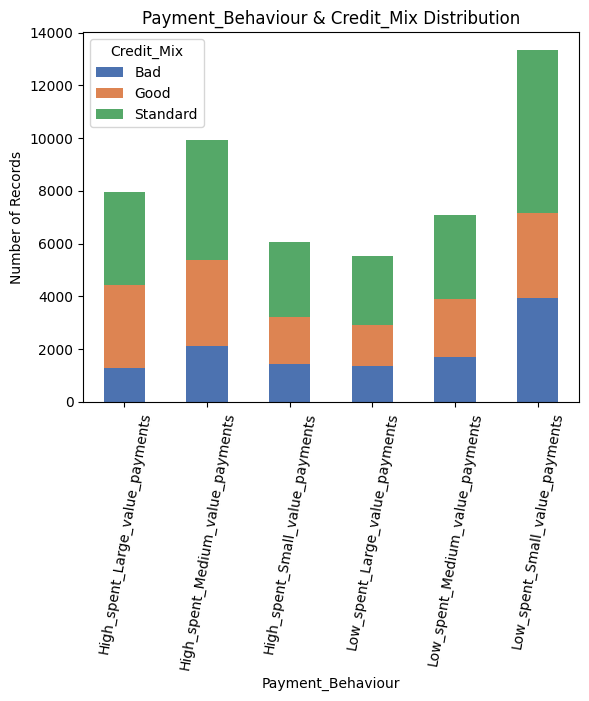

In [35]:
column_name = 'Payment_Behaviour'
group_by = 'Customer_ID'
garbage_value = '!@9#%8'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_categorical_field(df_train,group_by,column_name,garbage_value)

#Plot Distribution with Credit_Score
plot_stacked_bar(df_train,column_name,'Credit_Mix',rotation=80)

In [36]:
from scipy import stats

def fix_inconsistent_values(df, groupby, column):
    df_dropped = df[df[column].notna()].groupby(groupby)[column].apply(list)
    # Apply mode and handle cases where mode is empty
    x = df_dropped.apply(lambda x: stats.mode(x).mode[0] if not stats.mode(x).mode.size == 0 else np.nan)
    y = df_dropped.apply(lambda x: stats.mode(x).mode[0] if not stats.mode(x).mode.size == 0 else np.nan)
    
    mini, maxi = x.min(), y.max()
    
    # Correct the condition for inconsistent values
    col = df[column].apply(lambda x: np.NaN if ((x < mini) | (x > maxi) | (x < 0)) else x)
    
    # Apply to DataFrame
    df[column] = col


In [37]:
import numpy as np
import pandas as pd

def fix_inconsistent_values(df, groupby, column):
    # Grouping by the 'groupby' column and applying a list of values in the 'column' to each group
    df_dropped = df[df[column].notna()].groupby(groupby)[column].apply(list)
    
    # Apply mode and handle cases where mode is empty
    def get_mode(x):
        # Using pandas mode function for a more robust solution
        mode_result = pd.Series(x).mode()
        if not mode_result.empty:
            return mode_result.iloc[0]  # Return the first mode if available
        else:
            return np.nan  # If no mode, return NaN

    # Apply the safe get_mode function to each group
    x = df_dropped.apply(get_mode)
    
    # Handling min and max values for the column
    mini, maxi = x.min(), x.max()

    # Replace values outside the min/max range with NaN
    df[column] = df[column].apply(lambda val: np.nan if val < mini or val > maxi else val)

    # Return the cleaned dataframe
    return df


In [38]:
# Assuming df_train is your DataFrame, and 'Customer_ID' is the group column
column_name = 'Annual_Income'
group_by = 'Customer_ID'

# Clean the numerical field
df_train = fix_inconsistent_values(df_train, group_by, column_name)


Details of Monthly_Inhand_Salary column

DataType:  float64

There are  7498  null values

Number of Unique Values:  12793

Distribution of column:

Monthly_Inhand_Salary
1315.560833     8
6639.560000     7
2295.058333     7
6082.187500     7
536.431250      7
               ..
12386.966240    1
5993.870000     1
6763.330000     1
7729.695181     1
2312.785000     1
Name: count, Length: 12793, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Monthly Inhand Salary Distribution


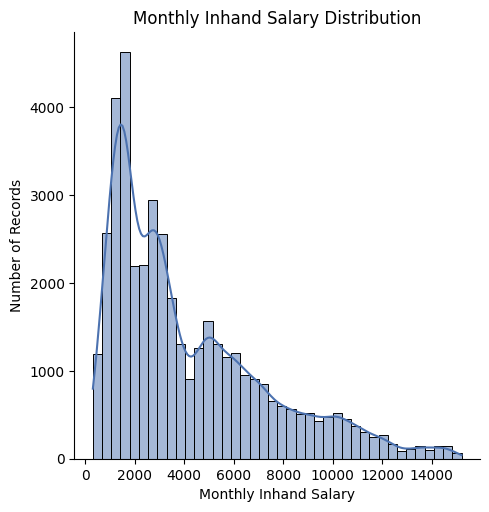

In [39]:
column_name = 'Monthly_Inhand_Salary'
group_by = 'Customer_ID'
user_friendly_name = 'Monthly Inhand Salary'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,bins=40)

Details of Num_Bank_Accounts column

DataType:  int64

There are no null values

Number of Unique Values:  540

Distribution of column:

Num_Bank_Accounts
6       6504
7       6408
8       6387
4       6100
5       6068
        ... 
855        1
1262       1
908        1
603        1
1727       1
Name: count, Length: 540, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Number of Bank Accounts Distribution


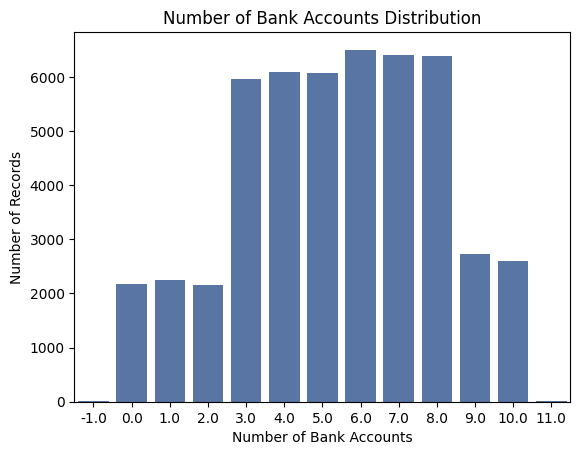

In [40]:
column_name = 'Num_Bank_Accounts'
group_by = 'Customer_ID'
user_friendly_name = 'Number of Bank Accounts'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name)

Details of Num_Credit_Card column

DataType:  int64

There are no null values

Number of Unique Values:  819

Distribution of column:

Num_Credit_Card
5       9210
7       8271
6       8243
4       7072
3       6539
        ... 
662        1
445        1
78         1
1488       1
955        1
Name: count, Length: 819, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Number of Credit Card Distribution


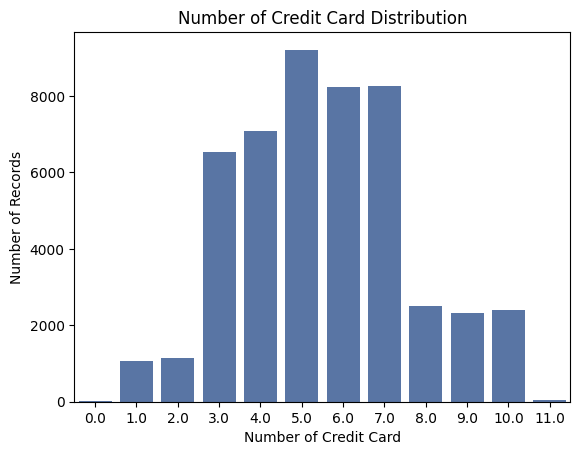

In [41]:
column_name = 'Num_Credit_Card'
group_by = 'Customer_ID'
user_friendly_name = 'Number of Credit Card'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name)

Details of Interest_Rate column

DataType:  int64

There are no null values

Number of Unique Values:  945

Distribution of column:

Interest_Rate
8       2503
5       2500
6       2368
12      2288
10      2259
        ... 
1573       1
3279       1
1166       1
5613       1
4252       1
Name: count, Length: 945, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Interest Rate Distribution


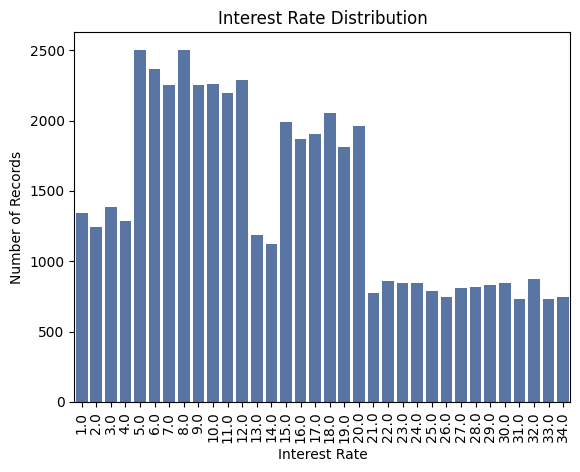

In [42]:
column_name = 'Interest_Rate'
group_by = 'Customer_ID'
user_friendly_name = 'Interest Rate'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name,rotation=90)

Details of Delay_from_due_date column

DataType:  int64

There are no null values

Number of Unique Values:  73

Distribution of column:

Delay_from_due_date
 13    1761
 15    1759
 8     1680
 9     1656
 10    1645
       ... 
 65      30
 63      21
-5       18
 66      12
 67       7
Name: count, Length: 73, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Delay from Due Date Distribution


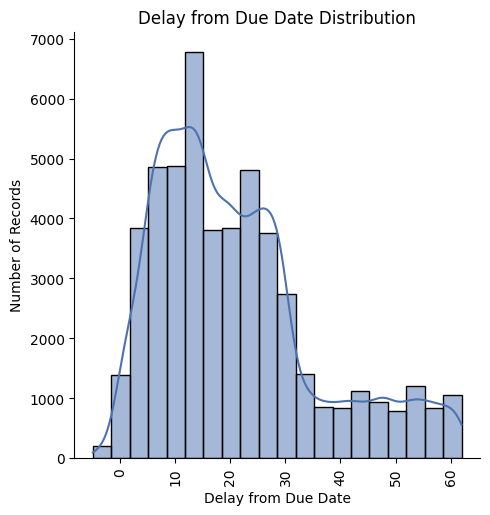

In [43]:
column_name = 'Delay_from_due_date'
group_by = 'Customer_ID'
user_friendly_name = 'Delay from Due Date'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,rotation=90)

Details of Num_of_Delayed_Payment column

DataType:  object

There are  3498  null values

Number of Unique Values:  443

Distribution of column:

Num_of_Delayed_Payment
19      2622
15      2594
18      2570
16      2548
17      2545
        ... 
288        1
3556       1
3393       1
4351       1
2034       1
Name: count, Length: 443, dtype: int64

-----------------------------------------------------

Cleaning steps 

Trailing & leading _ are removed

Datatype of Num_of_Delayed_Payment is changed to float

-----------------------------------------------------

Number of Delayed Payment Distribution


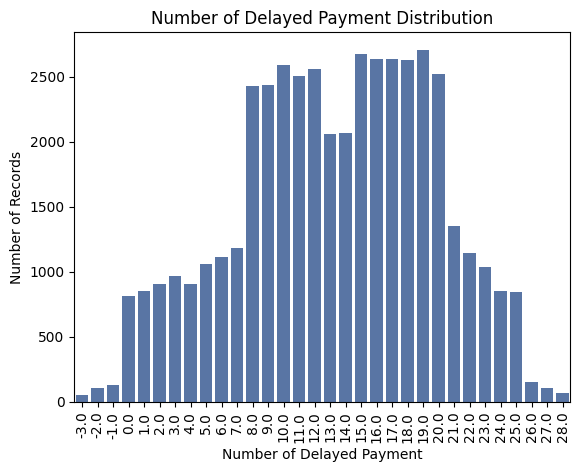

In [44]:
column_name = 'Num_of_Delayed_Payment'
group_by = 'Customer_ID'
user_friendly_name = 'Number of Delayed Payment'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,strip='_',datatype='float')

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name,rotation=90)

Details of Changed_Credit_Limit column

DataType:  object

There are no null values

Number of Unique Values:  3927

Distribution of column:

Changed_Credit_Limit
_                      1059
11.5                     70
11.32                    63
7.01                     60
7.35                     60
                       ... 
-0.6099999999999999       1
21.61                     1
12.010000000000002        1
0.43000000000000016       1
29.17                     1
Name: count, Length: 3927, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value _ is replaced with np.nan

Trailing & leading _ are removed

Datatype of Changed_Credit_Limit is changed to float

-----------------------------------------------------

Changed Credit Limit Distribution


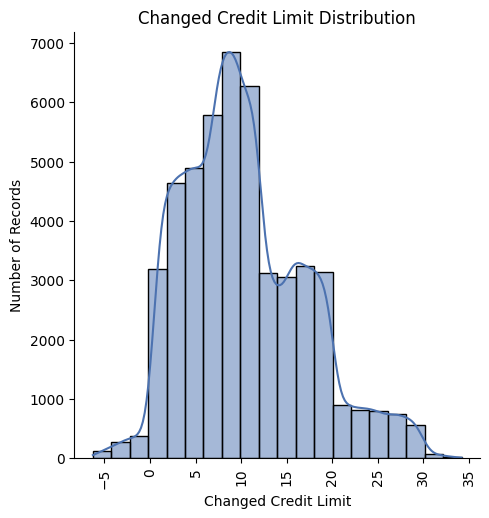

In [45]:
column_name = 'Changed_Credit_Limit'
group_by = 'Customer_ID'
user_friendly_name = 'Changed Credit Limit'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,strip='_',datatype='float',replace_value='_')

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,rotation=90)

Details of Num_Credit_Inquiries column

DataType:  float64

There are  1035  null values

Number of Unique Values:  750

Distribution of column:

Num_Credit_Inquiries
5.0       4709
4.0       4402
6.0       4375
7.0       4295
8.0       3922
          ... 
1471.0       1
307.0        1
1326.0       1
904.0        1
352.0        1
Name: count, Length: 750, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Number of Credit Inquiries Distribution


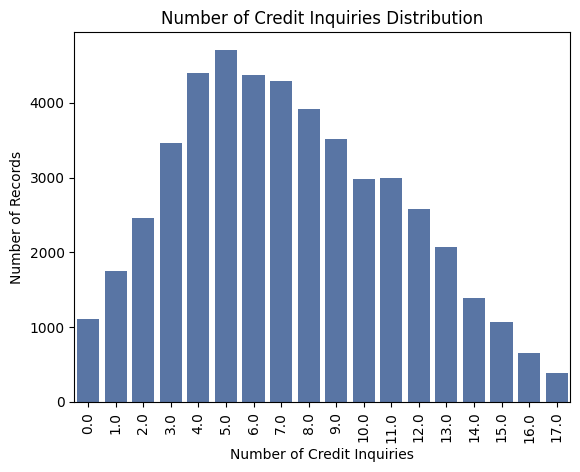

In [46]:
column_name = 'Num_Credit_Inquiries'
group_by = 'Customer_ID'
user_friendly_name = 'Number of Credit Inquiries'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name,rotation=90)

Details of Outstanding_Debt column

DataType:  object

There are no null values

Number of Unique Values:  12685

Distribution of column:

Outstanding_Debt
1109.03     12
1360.45     12
460.46      12
1151.7      12
1319.87      8
            ..
1443.78_     1
3534.9_      1
4320.49_     1
2982.66_     1
3223.66_     1
Name: count, Length: 12685, dtype: int64

-----------------------------------------------------

Cleaning steps 

Trailing & leading _ are removed

Datatype of Outstanding_Debt is changed to <class 'float'>

-----------------------------------------------------

Outstanding Debt Distribution


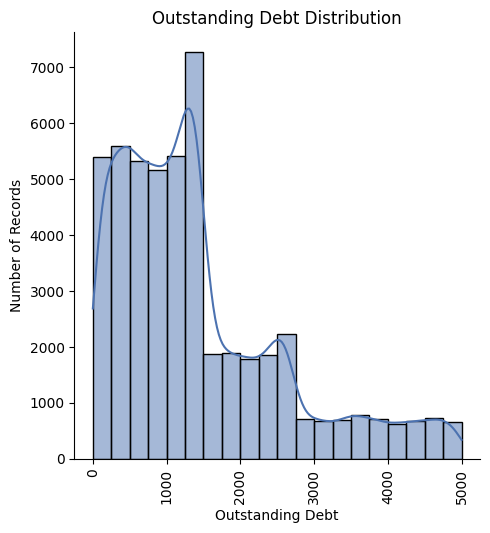

In [47]:
column_name = 'Outstanding_Debt'
group_by = 'Customer_ID'
user_friendly_name = 'Outstanding Debt'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,strip='_',datatype=float)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,rotation=90)

Details of Credit_Utilization_Ratio column

DataType:  float64

There are no null values

Number of Unique Values:  50000

Distribution of column:

Credit_Utilization_Ratio
35.030402    1
24.962925    1
32.546656    1
35.641022    1
27.277364    1
            ..
40.725304    1
33.004488    1
26.441658    1
24.342582    1
34.108530    1
Name: count, Length: 50000, dtype: int64

-----------------------------------------------------

Credit Utilization Ratio Distribution


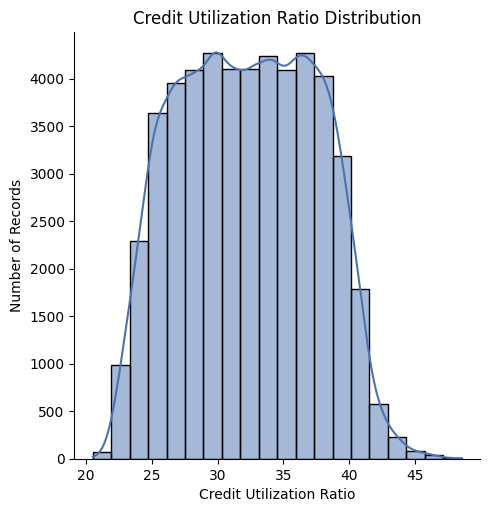

In [48]:
column_name = 'Credit_Utilization_Ratio'
group_by = 'Customer_ID'
user_friendly_name = 'Credit Utilization Ratio'

#Get Details
get_column_details(df_train,column_name)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name)

In [49]:
df_train['Credit_History_Age'].value_counts()

Credit_History_Age
20 Years and 1 Months     254
16 Years and 1 Months     254
18 Years and 7 Months     252
19 Years and 7 Months     252
18 Years and 6 Months     250
                         ... 
4 Years and 5 Months       21
0 Years and 11 Months      16
33 Years and 11 Months     15
34 Years and 0 Months      14
0 Years and 10 Months      13
Name: count, Length: 399, dtype: int64

In [50]:
def Month_Converter(val):
    if pd.notnull(val):
        years = int(val.split(' ')[0])
        month = int(val.split(' ')[3])
        return (years*12)+month
    else:
        return val
    
df_train['Credit_History_Age'] = df_train['Credit_History_Age'].apply(lambda x: Month_Converter(x)).astype(float)

Details of Credit_History_Age column

DataType:  float64

There are  4470  null values

Number of Unique Values:  399

Distribution of column:

Credit_History_Age
241.0    254
193.0    254
223.0    252
235.0    252
222.0    250
        ... 
53.0      21
11.0      16
407.0     15
408.0     14
10.0      13
Name: count, Length: 399, dtype: int64

-----------------------------------------------------

Cleaning steps 

Datatype of Credit_History_Age is changed to <class 'float'>

-----------------------------------------------------

Credit History Age Distribution


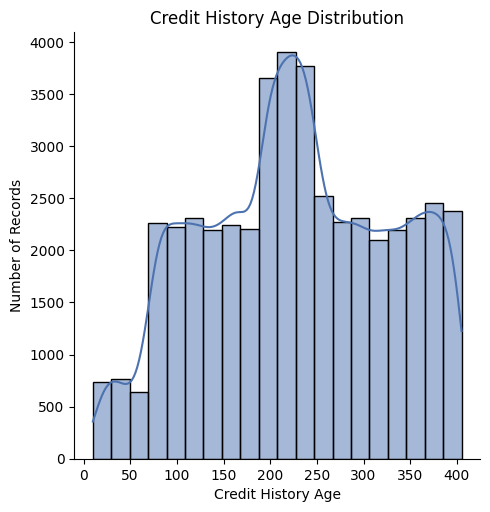

In [51]:
column_name = 'Credit_History_Age'
group_by = 'Customer_ID'
user_friendly_name = 'Credit History Age'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,datatype=float)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name)

Details of Total_EMI_per_month column

DataType:  float64

There are no null values

Number of Unique Values:  13144

Distribution of column:

Total_EMI_per_month
0.000000        5002
49.574949          4
16.941903          4
420.199367         4
550.679394         4
                ... 
65628.000000       1
92.396923          1
191.296729         1
61274.000000       1
50090.000000       1
Name: count, Length: 13144, dtype: int64

-----------------------------------------------------

Cleaning steps 

-----------------------------------------------------

Total EMI per month Distribution


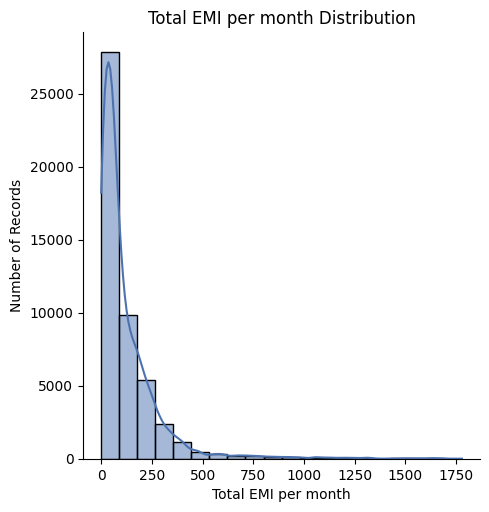

In [52]:
column_name = 'Total_EMI_per_month'
group_by = 'Customer_ID'
user_friendly_name = 'Total EMI per month'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name)

Details of Amount_invested_monthly column

DataType:  object

There are  2271  null values

Number of Unique Values:  45450

Distribution of column:

Amount_invested_monthly
__10000__             2175
0.0                    106
236.64268203272135       1
160.0977166999812        1
320.4566446914704        1
                      ... 
197.2171314766754        1
366.23148415217315       1
34.89940643392877        1
256.90830529853173       1
220.45787812168732       1
Name: count, Length: 45450, dtype: int64

-----------------------------------------------------

Cleaning steps 

Trailing & leading _ are removed

Datatype of Amount_invested_monthly is changed to <class 'float'>

-----------------------------------------------------

Amount invested monthly Distribution


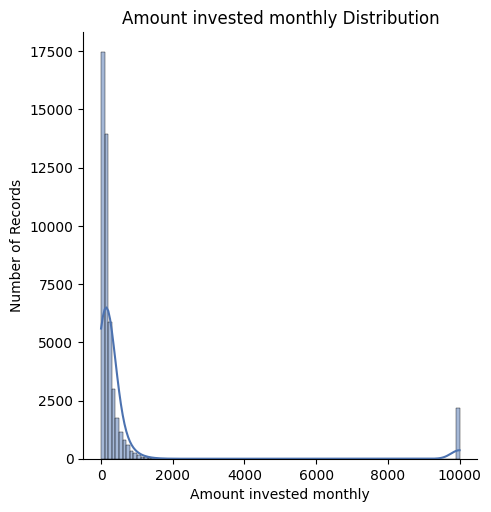

In [53]:
column_name = 'Amount_invested_monthly'
group_by = 'Customer_ID'
user_friendly_name = 'Amount invested monthly'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,datatype=float,strip='_')

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,bins=100)

Details of Monthly_Balance column

DataType:  object

There are  562  null values

Number of Unique Values:  49433

Distribution of column:

Monthly_Balance
__-333333333333333333333333333__    6
186.26670208571772                  1
223.40782977501067                  1
305.43786598764547                  1
389.53754307843735                  1
                                   ..
421.25686767906984                  1
194.44026842190848                  1
299.957837924029                    1
375.897928536186                    1
360.37968260123847                  1
Name: count, Length: 49433, dtype: int64

-----------------------------------------------------

Cleaning steps 

Garbage value __-333333333333333333333333333__ is replaced with np.nan

Trailing & leading _ are removed

Datatype of Monthly_Balance is changed to <class 'float'>

-----------------------------------------------------

Monthly Balance Distribution


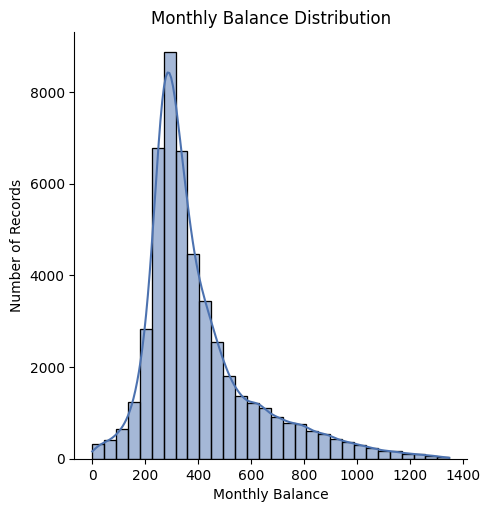

In [54]:
column_name = 'Monthly_Balance'
group_by = 'Customer_ID'
user_friendly_name = 'Monthly Balance'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
df_train[column_name].replace('',np.nan)
clean_numerical_field(df_train,group_by,column_name,strip='_',datatype=float,replace_value='__-333333333333333333333333333__')

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,bins=30)

Details of Num_of_Loan column

DataType:  object

There are no null values

Number of Unique Values:  263

Distribution of column:

Num_of_Loan
2        7173
3        7114
4        6982
0        5163
1        5029
         ... 
621         1
1040        1
1496        1
570         1
1296_       1
Name: count, Length: 263, dtype: int64

-----------------------------------------------------

Cleaning steps 

Trailing & leading _ are removed

Datatype of Num_of_Loan is changed to <class 'float'>

-----------------------------------------------------

Number of Loan Distribution


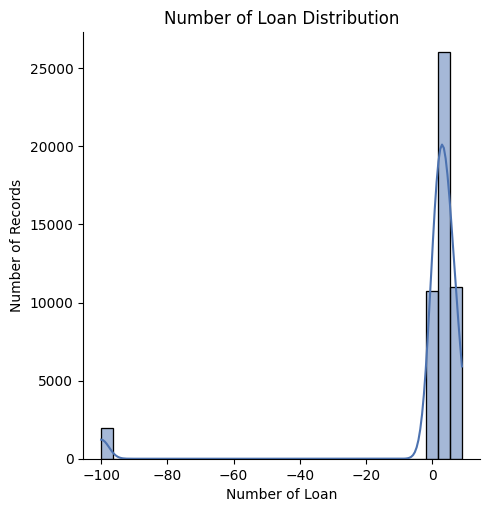

In [55]:
column_name = 'Num_of_Loan'
group_by = 'Customer_ID'
user_friendly_name = 'Number of Loan'

#Get Details
get_column_details(df_train,column_name)

#Cleaning
clean_numerical_field(df_train,group_by,column_name,strip='_',datatype=float)

#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,bins=30)

In [56]:
df_train.isna().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        5015
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  1
Monthly_Inhand_Salary       7498
Num_Bank_Accounts            635
Num_Credit_Card             1179
Interest_Rate                966
Num_of_Loan                  258
Type_of_Loan                   0
Delay_from_due_date          103
Num_of_Delayed_Payment      3893
Changed_Credit_Limit        1084
Num_Credit_Inquiries        1881
Credit_Mix                    84
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4542
Payment_of_Min_Amount          0
Total_EMI_per_month         1628
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              645
dtype: int64

In [57]:
print("Size of Dataset before dropping columns : ",df_train.shape)
drop_columns = ['ID','Customer_ID','Name','SSN']
df_train.drop(drop_columns,axis=1,inplace=True)
print("Size of Dataset after dropping columns : ",df_train.shape)

Size of Dataset before dropping columns :  (50000, 27)
Size of Dataset after dropping columns :  (50000, 23)


In [58]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ['Occupation','Type_of_Loan','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Credit_Mix']

label_encoder = LabelEncoder()

for column in categorical_columns:
    df_train[column] = label_encoder.fit_transform(df_train[column])

In [59]:
df_train.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,9,23,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,NaN,1,809.98,35.030402,273.0,1,49.574949,236.642682,5,186.266702
1,10,24,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,4.0,1,809.98,33.053114,274.0,1,49.574949,21.465380,1,361.444004
2,11,24,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,128,...,4.0,1,809.98,33.811894,NaN,1,49.574949,148.233938,4,264.675446
3,12,24_,12,19114.12,NaN,3.0,4.0,3.0,4.0,128,...,4.0,1,809.98,32.430559,276.0,1,49.574949,39.082511,1,343.826873
4,9,28,13,34847.84,3037.986667,2.0,4.0,6.0,1.0,684,...,5.0,1,605.03,25.926822,327.0,1,18.816215,39.684018,0,485.298434


In [60]:
#Spli Input & Output Data
X = df_train.drop('Credit_Mix',axis=1)
y = df_train['Credit_Mix']
print(X.shape)
print(y.shape)

(50000, 22)
(50000,)


In [63]:
from sklearn.preprocessing import MinMaxScaler

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns
print("Non-numeric columns:", non_numeric_cols)

# Display unique values in non-numeric columns
for col in non_numeric_cols:
    print(f"Unique values in '{col}':")
    print(X[col].unique())

# Convert columns with numeric values stored as strings (e.g., "$123", "45kg") to float
for col in non_numeric_cols:
    # Attempt to extract numbers if the column looks numeric with non-numeric characters
    X[col] = X[col].str.extract(r'(\d+\.?\d*)')[0]
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle missing values if any (optional, depends on your use case)
X = X.fillna(0)

# Now apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


Non-numeric columns: Index([], dtype='object')


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17,stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 22)
(10000, 22)
(40000,)
(10000,)


In [65]:
def evaluate_model(y_test,y_pred):
    print("Classification Report")
    print(classification_report(y_test, y_pred))
    
    print("\n---------------------------------------------\n")
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create a heatmap of the confusion matrix using Seaborn
    sns.heatmap(cm, annot=True, cmap='Greens',fmt='.0f')

    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')

    plt.show()

In [68]:
X_train = X_train.copy()

# Remove underscores and convert to numeric
X_train['Annual_Income'] = pd.to_numeric(X_train['Annual_Income'].astype(str).str.replace('_', '', regex=False), errors='coerce')
X_train['Age'] = pd.to_numeric(X_train['Age'].astype(str).str.replace('_', '', regex=False), errors='coerce')

# Fill missing values with column means
X_train['Annual_Income'] = X_train['Annual_Income'].fillna(X_train['Annual_Income'].mean())
X_train['Age'] = X_train['Age'].fillna(X_train['Age'].mean())

# Fill other missing values if any
X_train = X_train.fillna(X_train.mean())

# ----------- CLASSIFIERS AND EVALUATION -----------

from sklearn.metrics import make_scorer, precision_score, recall_score

precision_macro = make_scorer(precision_score, average='macro', zero_division=0)
recall_macro = make_scorer(recall_score, average='macro', zero_division=0)

for clf_name, clf in classifiers:
    try:
        accuracy = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean()
        precision = cross_val_score(clf, X_train, y_train, cv=5, scoring=precision_macro).mean()
        recall = cross_val_score(clf, X_train, y_train, cv=5, scoring=recall_macro).mean()

        print(f'Classifier: {clf_name}')
        print(f'Average Accuracy: {accuracy:.4f}')
        print(f'Average Precision: {precision:.4f}')
        print(f'Average Recall: {recall:.4f}')
        print('-----------------------')
    except Exception as e:
        print(f"Error evaluating {clf_name}: {e}")
        print(f"Error evaluating {clf_name}: {e}")

Classifier: Decision Tree
Average Accuracy: 0.9382
Average Precision: 0.7735
Average Recall: 0.7928
-----------------------
Classifier: Random Forest
Average Accuracy: 0.9667
Average Precision: 0.8753
Average Recall: 0.7349
-----------------------
Classifier: KNN
Average Accuracy: 0.7189
Average Precision: 0.6554
Average Recall: 0.5683
-----------------------
Classifier: Gaussian NB
Average Accuracy: 0.6188
Average Precision: 0.4799
Average Recall: 0.4784
-----------------------


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:55:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:55:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:55:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:56:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

Classifier: XGB
Average Accuracy: 0.9729
Average Precision: 0.9798
Average Recall: 0.8433
-----------------------


In [ ]:
print(X_train.head())
print(X_train.dtypes)
print(y_train.head())

In [ ]:
# Remove any underscores and non-numeric characters
X_train['Annual_Income'] = X_train['Annual_Income'].astype(str).str.replace('_', '', regex=False)
X_train['Age'] = X_train['Age'].astype(str).str.replace('_', '', regex=False)

# Convert columns to numeric (invalid entries will become NaN)
X_train['Annual_Income'] = pd.to_numeric(X_train['Annual_Income'], errors='coerce')
X_train['Age'] = pd.to_numeric(X_train['Age'], errors='coerce')

# Fill missing values with column means
X_train['Annual_Income'] = X_train['Annual_Income'].fillna(X_train['Annual_Income'].mean())
X_train['Age'] = X_train['Age'].fillna(X_train['Age'].mean())

# Fill other missing values if any (across the entire DataFrame)
X_train = X_train.fillna(X_train.mean())

# Repeat this same data cleaning process for your X_test as well
X_test['Annual_Income'] = X_test['Annual_Income'].astype(str).str.replace('_', '', regex=False)
X_test['Age'] = X_test['Age'].astype(str).str.replace('_', '', regex=False)

X_test['Annual_Income'] = pd.to_numeric(X_test['Annual_Income'], errors='coerce')
X_test['Age'] = pd.to_numeric(X_test['Age'], errors='coerce')

X_test['Annual_Income'] = X_test['Annual_Income'].fillna(X_test['Annual_Income'].mean())
X_test['Age'] = X_test['Age'].fillna(X_test['Age'].mean())
X_test = X_test.fillna(X_test.mean())

# Now train the RandomForest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
evaluate_model(y_test, y_pred)


In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the classifier
rf_classifier.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluating the model
evaluate_model(y_test, y_pred)